## **Imports**

In [1]:
import math
import os
import time
import pickle

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

## **Functions**

In [2]:
class LowVarianceConditionalFlowMatcher(ConditionalFlowMatcher):
    """Child class for low-variance conditional flow matching method. This class implements
    a novel method for computing the vector field.

    It overrides the sample_location_and_conditional_flow.
    """

    def __init__(self, p0, sigma: Union[float, int] = 0.0):
        r"""Initialize the ConditionalFlowMatcher class. It requires the hyper-parameter $\sigma$.

        Parameters
        ----------
        p0 : Probability density function for t=0. Must implement the log_prob method.
        vector_field_batch_size : size of the mini-batch used for computing the approximate marginal vector field.
        sigma : Union[float, int]
        """
        super().__init__(sigma)
        self.p0 = p0

    def sample_location_and_conditional_flow(self, x0, x1, x1_vf_batch, t=None, return_noise=False):
        r"""
        Compute the sample xt (drawn from N(t * x1 + (1 - t) * x0, sigma))
        and an estimate of the marginal vector field ut, 
        computed with respect to the minibatch.

        Parameters
        ----------
        x0 : Tensor, shape (bs, *dim)
            represents the source minibatch
        x1 : Tensor, shape (bs, *dim)
            represents the target minibatch
        x1_vf_batch : Tensore, shape (vfbs, *dim)
            a second minibatch from the target distribution, used for computing the marginal vector field
        (optionally) t : Tensor, shape (bs)
            represents the time levels
            if None, drawn from uniform [0,1]
        return_noise : bool
            return the noise sample epsilon

        Returns
        -------
        t : FloatTensor, shape (bs)
        xt : Tensor, shape (bs, *dim)
            represents the samples drawn from probability path pt
        ut : marginal vector field ut
        (optionally) epsilon : Tensor, shape (bs, *dim) such that xt = mu_t + sigma_t * epsilon
        """
        if t is None:
            t = torch.rand(x0.shape[0]).type_as(x0)
        assert len(t) == x0.shape[0], "t has to have batch size dimension"

        eps = self.sample_noise_like(x0)
        xt = self.sample_xt(x0, x1, t, eps)

        # compute an estimate of the marginal vector field
        ut = torch.zeros_like(xt)
        deno = 1-(1-self.sigma)*t
        for i in range(x0.shape[0]):
            # make sure that the value of x1 that generated xt[i] is in the batch to avoid 
            # having all probabilities equal to zero
            x1_vf_batch[0] = x1[i]
            # batch computation of the values of x0 corresponding to xt[i] and the dataset of x1
            x0_xbar = (xt[i] - t[i]*x1_vf_batch)/deno[i]
            # batch computation of the probabilities associated to these values of x0
            prob = torch.exp(self.p0.log_prob(x0_xbar))
            norm_prob = prob / torch.sum(prob).item()
            # estimate the vector field
            v_batch = (x1_vf_batch - (1-self.sigma)*xt[i]) / deno[i]
            ut[i] = torch.sum(norm_prob * v_batch.T, dim=1)

        return t, xt, ut


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    return lambda x, *args: torch.trace(J(x))

class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps()

    def get_div_and_eps(self):
        return exact_div_fn, None

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)
    

def plot_my_trajectories(p0, model, x1, plot_size):
    """Plot trajectories of some selected samples."""
    node = NeuralODE(torch_wrapper(model), solver="dopri5", sensitivity="adjoint", 
                atol=1e-4, rtol=1e-4)
    traj = node.trajectory(p0.sample([plot_size]),
                        t_span=torch.linspace(0, 1, 100),).cpu().numpy()
    # evaluate FID score
    # x1_gen = traj[-1,:,:]
    # fid_score = fid.fid_from_feats(x1_gen, x1_plot)
    n = 2000
    plt.figure(figsize=(6, 6))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.6, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.2, alpha=0.1, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=0.6, c="blue")
    plt.scatter(x1[:,0], x1[:,1], s=4, alpha=0.6, c="red")
    plt.legend(["Prior sample z(S)", "Flow", "z(0)", "Targets"])
    plt.grid(True)

def compute_neg_log_likelihood(x1, p0, model):
    # evaluate negative log likelihood that sampling p0 and integrating the given vector field
    # (model) we get the given samples x1.
    cnf = NeuralODE(
        cnf_wrapper(model), solver="dopri5", sensitivity="adjoint", 
        atol=1e-4, rtol=1e-4
    )
    with torch.no_grad():
        x1_with_ll = torch.cat([x1, torch.zeros(x1.shape[0], 1)], dim=-1)
        x0_with_ll = cnf.trajectory(x1_with_ll, t_span=torch.tensor([1.0, 0.0]))[-1]
        logprob = p0.log_prob(x0_with_ll[..., :-1]) + x0_with_ll[..., -1]
        nll_score = -torch.mean(logprob)
    return nll_score
    
def sample_target_distribution(size):
    if(DATASET=="moons"):
        return sample_moons(size)
    return p1.sample([size])

def get_test_name(method, buffer_size, vf_batch_size):
    if(method=="NOVEL"):
        return method+"_buff_"+str(buffer_size)+"_vfbs_"+str(vf_batch_size)
    return method

## **Training**

Prepare data buffer of 156 elements
Using training method NOVEL
Using VF batch size 2048
Done preparing data buffer. It took 2.512 s
Start training with buffer size 156 and VF batch size 2048
1: loss 2.841 NLL 6.221 time 0.00
1000: loss 0.091 NLL 2.934 time 0.70
2000: loss 0.079 NLL 2.768 time 0.71
3000: loss 0.046 NLL 2.643 time 0.67
4000: loss 0.029 NLL 2.585 time 0.82
5000: loss 0.050 NLL 2.588 time 0.63
6000: loss 0.044 NLL 2.624 time 0.86
7000: loss 0.039 NLL 2.517 time 0.87
8000: loss 0.037 NLL 2.558 time 0.87
9000: loss 0.059 NLL 2.562 time 0.87
10000: loss 0.028 NLL 2.528 time 0.88
11000: loss 0.030 NLL 2.504 time 0.77
12000: loss 0.030 NLL 2.499 time 0.56
13000: loss 0.028 NLL 2.514 time 0.56
14000: loss 0.019 NLL 2.507 time 0.56
15000: loss 0.041 NLL 2.504 time 0.56
16000: loss 0.021 NLL 2.511 time 0.56
17000: loss 0.029 NLL 2.495 time 0.71
18000: loss 0.034 NLL 2.509 time 0.63
19000: loss 0.029 NLL 2.507 time 0.57
20000: loss 0.032 NLL 2.486 time 0.56
21000: loss 0.034 NLL 2

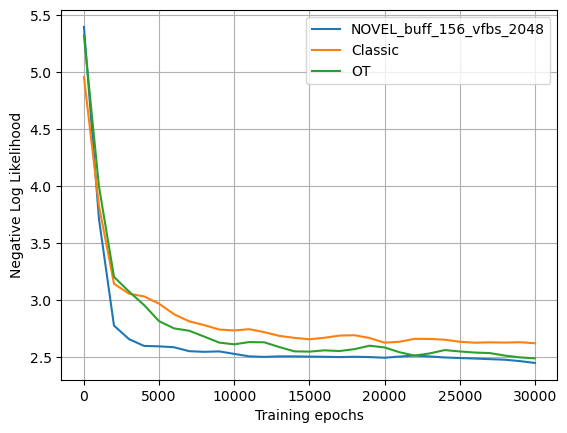

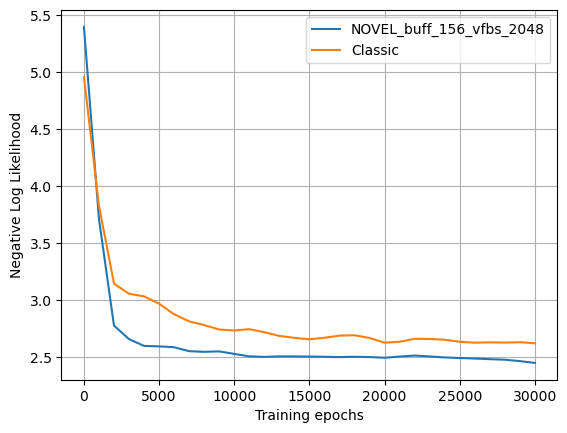

In [5]:
savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)
SAVE_DATA = True
LOAD_DATA = 0
METHOD = "NOVEL" # STANDARD_CFM or OPTIMAL_TRANSPORT or NOVEL
DATASET = "moons"
batch_size = 128
TRAINING_EPOCHS = 30000

# size of the minibatch used for estimating the marginal vector field
VF_BATCH_SIZES = [2048] # 32 or 64 both worked very well, at least 16 to get decent results
# VF_BATCH_SIZES = [16, 32, 64] # at least 16

# size of the training buffer
BUFFER_SIZES = [int(10000/64)]
# BUFFER_SIZES = [int(10000/32),
#                 int(10000/64),
#                 int(10000/128)]

NTESTS = int(TRAINING_EPOCHS/30)
DO_PLOTS = False
sigma = 0.01
dim = 2
test_size = 1024

# ot_sampler = OTPlanSampler(method="exact")
p0 = torch.distributions.MultivariateNormal(torch.zeros(dim), torch.eye(dim))
p1 = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 3])),
    torch.distributions.Independent(torch.distributions.Normal(
        torch.tensor([[-5., -4], [6., 9.]]), torch.tensor([[1., 3.], [2., 1.]])), 1)
)
if METHOD=="NOVEL":
    CFM = LowVarianceConditionalFlowMatcher(p0, sigma)
elif METHOD=="STANDARD_CFM":
    CFM = ConditionalFlowMatcher (sigma)
elif METHOD=="OPTIMAL_TRANSPORT":
    CFM = ExactOptimalTransportConditionalFlowMatcher(sigma)

if(LOAD_DATA):
    nll_scores = pickle.load(open("nll_scores_novel", "rb"))
    epochs = pickle.load(open("epochs_novel", "rb"))
else:
    epochs, nll_scores = {}, {}
    t_vs_p = []
    x1_test = sample_target_distribution(test_size)
    for vf_batch_size in VF_BATCH_SIZES:
        data_buffer = []
        buffer_size = np.max(BUFFER_SIZES)
        # First fill out the data buffer 
        print(f"Prepare data buffer of {buffer_size} elements")
        print("Using training method", METHOD)
        start = time.time()
        if(METHOD == "OPTIMAL_TRANSPORT" or METHOD=="STANDARD_CFM"):
            for k in range(TRAINING_EPOCHS):
                x0 = p0.sample([batch_size])
                x1 = sample_target_distribution(batch_size)
                # # Draw samples from OT plan
                # if(METHOD == "OPTIMAL_TRANSPORT"):
                #     x0, x1 = ot_sampler.sample_plan(x0, x1)
                t, xt, ut = CFM.sample_location_and_conditional_flow(x0, x1)
                data_buffer.append([t, xt, ut])
        else:
            print(f"Using VF batch size {vf_batch_size}")
            for k in range(int(buffer_size)):
                x0 = p0.sample([batch_size])
                x1 = sample_target_distribution(batch_size)
                x1_vf_batch = sample_target_distribution(vf_batch_size)
                t, xt, ut = CFM.sample_location_and_conditional_flow(x0, x1, x1_vf_batch)
                data_buffer.append([t, xt, ut])
        data_prep_time = time.time()-start
        print(f"Done preparing data buffer. It took {data_prep_time:0.3f} s")

        for buffer_size in BUFFER_SIZES:
            # use only the first buffer_size elements of the buffer
            test_name = get_test_name(METHOD, buffer_size, vf_batch_size)
            epochs[test_name] = []
            nll_scores[test_name] = []

            # Then train the network using the data in the buffer
            print("Start training with buffer size", buffer_size, "and VF batch size", vf_batch_size)
            model = MLP(dim=dim, time_varying=True)
            optimizer = torch.optim.Adam(model.parameters())
            start = time.time()
            for k in range(TRAINING_EPOCHS):
                [t, xt, ut] = data_buffer[np.random.randint(buffer_size)]
                vt = model(torch.cat([xt, t[:, None]], dim=-1))
                loss = torch.mean((vt - ut) ** 2)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

                if (k + 1) % NTESTS == 0 or k==0:
                    end = time.time()
                    with torch.no_grad():
                        # evaluate negative log likelihood
                        nll_score = compute_neg_log_likelihood(x1_test, p0, model)
                        epochs[test_name].append(k)
                        nll_scores[test_name].append(nll_score)
                        print(f"{k+1}: loss {loss.item():0.3f} NLL {nll_score:0.3f} time {(end - start):0.2f}")
                        if(DO_PLOTS):
                            plot_my_trajectories(p0, model, x1_test, test_size)
                    start = time.time()
    if(SAVE_DATA):
        pickle.dump(nll_scores, open("nll_scores_novel", "wb"))
        pickle.dump(epochs, open("epochs_novel", "wb"))

if(METHOD=="STANDARD_CFM"):
    np.savez("nll_standard_cfm.npz", epochs=epochs, nnl_scores=nll_scores)
if (METHOD=="OPTIMAL_TRANSPORT"):
    np.savez("nll_OT_cfm.npz", epochs=epochs, nnl_scores=nll_scores)

def filter_data(v):
    out = len(v)*[0.0,]
    for i in range(1, len(v)-1):
        out[i] = (v[i-1] + 2*v[i] + v[i+1])*0.25
    out[0] = (3*v[0] + v[1])*0.25
    out[-1] = (v[-2] + 3*v[-1])*0.25
    return out

if(METHOD=="NOVEL"):
    for vf_batch_size in VF_BATCH_SIZES:
        plt.figure()
        for k in epochs.keys():
            if(str(vf_batch_size) in k):
                plt.plot(epochs[k], filter_data(nll_scores[k]), label=k)
        data = np.load("nll_standard_cfm.npz", allow_pickle=True)
        epochs_classic = data["epochs"].item()['STANDARD_CFM']
        nll_classic = data["nnl_scores"].item()['STANDARD_CFM']
        plt.plot(epochs_classic, filter_data(nll_classic), label="Classic")

        data = np.load("nll_OT_cfm.npz", allow_pickle=True)
        epochs_ot = data["epochs"].item()['OPTIMAL_TRANSPORT']
        nll_ot = data["nnl_scores"].item()['OPTIMAL_TRANSPORT']
        plt.plot(epochs_ot, filter_data(nll_ot), label="OT")
        plt.legend()
        plt.ylabel("Negative Log Likelihood")
        plt.xlabel("Training epochs")
        plt.grid(True)

    for buffer_size in BUFFER_SIZES:
        plt.figure()
        for k in epochs.keys():
            if(str(buffer_size) in k):
                plt.plot(epochs[k], filter_data(nll_scores[k]), label=k)
        data = np.load("nll_standard_cfm.npz", allow_pickle=True)
        epochs_classic = data["epochs"].item()['STANDARD_CFM']
        nll_classic = data["nnl_scores"].item()['STANDARD_CFM']
        plt.plot(epochs_classic, filter_data(nll_classic), label="Classic")
        plt.legend()
        plt.ylabel("Negative Log Likelihood")
        plt.xlabel("Training epochs")
        plt.grid(True)
else:
    plt.figure()
    for k in epochs.keys():
        plt.plot(epochs[k], filter_data(nll_scores[k]), label=k)
    data = np.load("nll_standard_cfm.npz")
    plt.plot(data["epochs"], filter_data(data["nnl_scores"]), label="Classic")
    plt.legend()
    plt.ylabel("Negative Log Likelihood")
    plt.xlabel("Training epochs")
    plt.grid(True)

plt.show()